In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_pd = pd.read_csv('train.csv')
test_pd = pd.read_csv('test.csv')

display(train_pd)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
survived = train_pd['Survived']
train_pd = train_pd.drop(['Survived'], axis=1)

display(train_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
train_idx = train_pd['PassengerId']
test_idx = test_pd['PassengerId']

combined_pd = pd.concat([train_pd, test_pd]).reset_index(drop=True)

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
print('NULL VALUES')
print(combined_pd.isnull().sum())

NULL VALUES
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


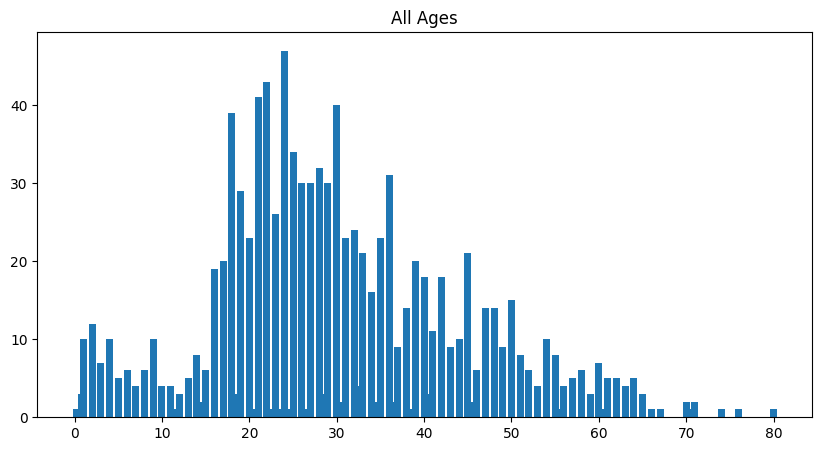

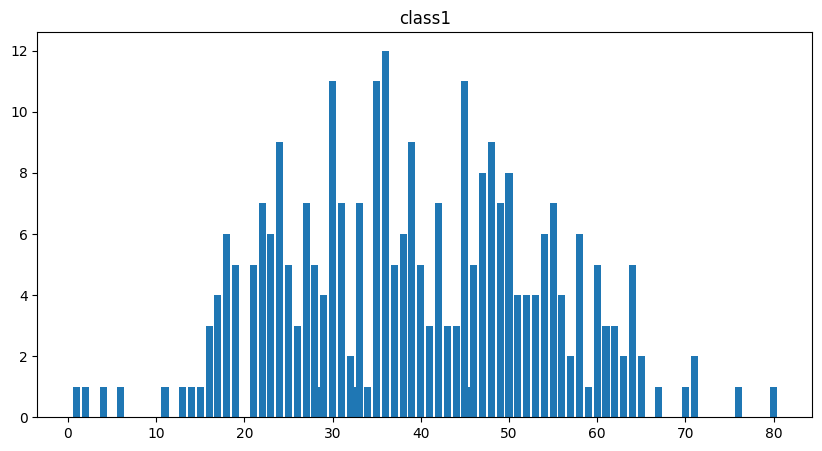

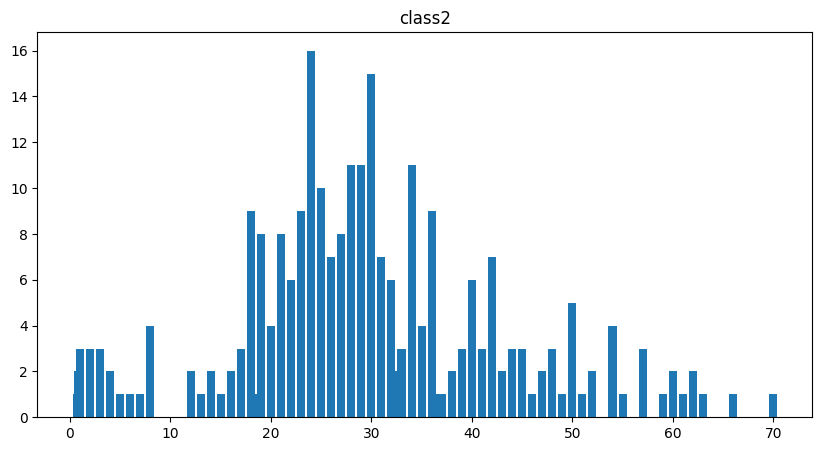

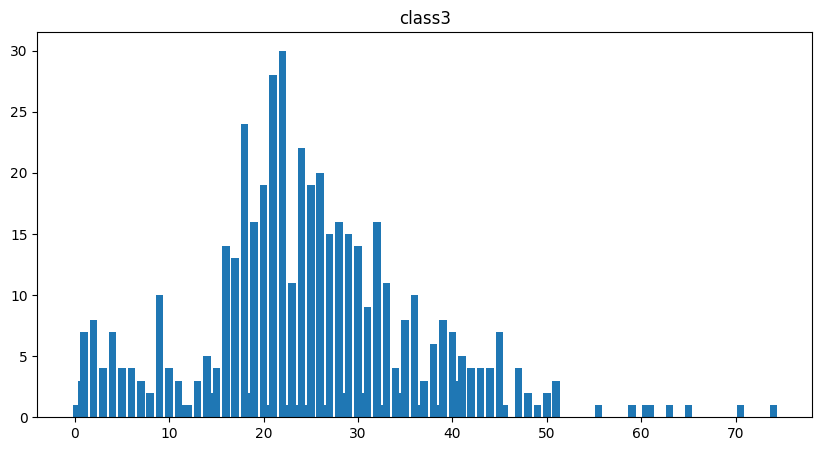

In [6]:
y = combined_pd['Age'].value_counts()
x = y.index.values

plt.figure(figsize=(10,5))
plt.bar(x,y)
plt.title("All Ages")
plt.show()

class_age = combined_pd[['Pclass', 'Age']]

for i in range(1,4):
    plt.figure(figsize=(10,5))
    plt.title("class" + str(i))
    y = class_age[class_age['Pclass']==i]['Age'].value_counts()
    x = y.index.values
    plt.bar(x,y)
    plt.show()

In [7]:
medians = class_age.groupby('Pclass').median()
print(medians)

         Age
Pclass      
1       39.0
2       29.0
3       24.0


In [8]:
for i in range(3):
    idx = np.where( (combined_pd['Pclass']==i+1) & (combined_pd['Age'].isnull()) )[0]
    combined_pd.loc[idx, 'Age'] = medians.values[i][0]

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S


In [9]:
display(combined_pd[combined_pd['Fare'].isnull()])
sim_fares = combined_pd[ (combined_pd['Pclass']==3) & (combined_pd['Embarked']=='S')]['Fare']
print("Median:", sim_fares.median())

# plt.hist(sim_fares)
# plt.plot()

combined_pd['Fare'] = combined_pd['Fare'].fillna(sim_fares.median())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


Median: 8.05


In [10]:
display(combined_pd[combined_pd['Embarked'].isnull()])
sim_embarked = combined_pd[ (combined_pd['Pclass'] == 1) & (combined_pd['Fare'] >= 70) & (combined_pd['Fare'] <= 90)]['Embarked']
print(sim_embarked.value_counts())

combined_pd['Embarked'] = combined_pd['Embarked'].fillna('C')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Embarked
C    29
S    25
Q     3
Name: count, dtype: int64


In [11]:
combined_pd['Cabin'] = combined_pd['Cabin'].fillna('M')
combined_pd['Cabin'] = combined_pd['Cabin'].str[0]
print(combined_pd['Cabin'].value_counts())

idx = np.where(combined_pd['Cabin']=='T')[0]
combined_pd.loc[idx, 'Cabin'] ='M'

Cabin
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64


In [12]:
print(combined_pd.isnull().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [13]:
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S


In [14]:
print(combined_pd.nunique())

PassengerId    1309
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin             8
Embarked          3
dtype: int64


In [15]:
print(combined_pd['Age'].min(), combined_pd['Age'].max())

0.17 80.0


In [16]:
Bins = np.array([0,10,20,30,40,50,60,70,80])
combined_pd['Age_Bins'] = pd.cut(combined_pd['Age'], Bins)

In [17]:
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Bins
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,"(20, 30]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,"(30, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,"(20, 30]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,"(30, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,"(30, 40]"
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,"(20, 30]"
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,"(30, 40]"
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,"(30, 40]"
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,"(20, 30]"


In [18]:
ticket_dict = dict(combined_pd['Ticket'].value_counts())
combined_pd['tct_count'] = combined_pd['Ticket'].map(ticket_dict)
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Bins,tct_count
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,"(20, 30]",1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,"(30, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,"(20, 30]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,"(30, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,"(30, 40]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,"(20, 30]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,"(30, 40]",3
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,"(30, 40]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,"(20, 30]",1


In [19]:
combined_pd['adj_fare'] = combined_pd['Fare']/combined_pd['tct_count']
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Bins,tct_count,adj_fare
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,"(20, 30]",1,7.250000
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,"(30, 40]",2,35.641650
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,"(20, 30]",1,7.925000
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,"(30, 40]",2,26.550000
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,"(30, 40]",1,8.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,"(20, 30]",1,8.050000
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,"(30, 40]",3,36.300000
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,"(30, 40]",1,7.250000
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,"(20, 30]",1,8.050000


In [20]:
print(combined_pd['adj_fare'].min(), combined_pd['adj_fare'].max())
Bins = [0,20,40,60,80,150]
combined_pd['Fare_bin'] = pd.cut(combined_pd['adj_fare'], Bins)
combined_pd['Num_family'] = combined_pd['SibSp'] + combined_pd['Parch'] + 1
display(combined_pd)

0.0 128.0823


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Bins,tct_count,adj_fare,Fare_bin,Num_family
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,"(20, 30]",1,7.250000,"(0, 20]",2
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,"(30, 40]",2,35.641650,"(20, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,"(20, 30]",1,7.925000,"(0, 20]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,"(30, 40]",2,26.550000,"(20, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,"(30, 40]",1,8.050000,"(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,"(20, 30]",1,8.050000,"(0, 20]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,"(30, 40]",3,36.300000,"(20, 40]",1
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,"(30, 40]",1,7.250000,"(0, 20]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,"(20, 30]",1,8.050000,"(0, 20]",1


In [21]:
combined_pd.drop(['Name', 'Age', 'Ticket', 'Fare', 'tct_count', 'adj_fare',], axis=1, inplace=True)
display(combined_pd)

,PassengerId,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Age_Bins,Fare_bin,Num_family
0,1,3,male,1,0,M,S,"(20, 30]","(0, 20]",2
1,2,1,female,1,0,C,C,"(30, 40]","(20, 40]",2
2,3,3,female,0,0,M,S,"(20, 30]","(0, 20]",1
3,4,1,female,1,0,C,S,"(30, 40]","(20, 40]",2
4,5,3,male,0,0,M,S,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,male,0,0,M,S,"(20, 30]","(0, 20]",1
1305,1306,1,female,0,0,C,C,"(30, 40]","(20, 40]",1
1306,1307,3,male,0,0,M,S,"(30, 40]","(0, 20]",1
1307,1308,3,male,0,0,M,S,"(20, 30]","(0, 20]",1


In [22]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [23]:
combined_pd.set_index('PassengerId', inplace=True)
display(combined_pd)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Age_Bins,Fare_bin,Num_family
PassengerId,,,,,,,,,
1,3,male,1,0,M,S,"(20, 30]","(0, 20]",2
2,1,female,1,0,C,C,"(30, 40]","(20, 40]",2
3,3,female,0,0,M,S,"(20, 30]","(0, 20]",1
4,1,female,1,0,C,S,"(30, 40]","(20, 40]",2
5,3,male,0,0,M,S,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...
1305,3,male,0,0,M,S,"(20, 30]","(0, 20]",1
1306,1,female,0,0,C,C,"(30, 40]","(20, 40]",1
1307,3,male,0,0,M,S,"(30, 40]","(0, 20]",1


In [24]:
label_enc = combined_pd.copy()
label_enc = combined_pd.astype(str)
label_enc = label_enc.apply(LabelEncoder().fit_transform)
display(label_enc)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Age_Bins,Fare_bin,Num_family
PassengerId,,,,,,,,,
1,2,1,1,0,7,2,2,0,2
2,0,0,1,0,2,0,3,1,2
3,2,0,0,0,7,2,2,0,0
4,0,0,1,0,2,2,3,1,2
5,2,1,0,0,7,2,3,0,0
...,...,...,...,...,...,...,...,...,...
1305,2,1,0,0,7,2,2,0,0
1306,0,0,0,0,2,0,3,1,0
1307,2,1,0,0,7,2,3,0,0


In [25]:
one_hot = label_enc.copy()

one_hot = pd.get_dummies(one_hot, columns=['Sex', 'Embarked'], dtype=int)

display(one_hot)

,Pclass,SibSp,Parch,Cabin,Age_Bins,Fare_bin,Num_family,Sex_0,Sex_1,Embarked_0,Embarked_1,Embarked_2
PassengerId,,,,,,,,,,,,
1,2,1,0,7,2,0,2,0,1,0,0,1
2,0,1,0,2,3,1,2,1,0,1,0,0
3,2,0,0,7,2,0,0,1,0,0,0,1
4,0,1,0,2,3,1,2,1,0,0,0,1
5,2,0,0,7,3,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1305,2,0,0,7,2,0,0,0,1,0,0,1
1306,0,0,0,2,3,1,0,1,0,1,0,0
1307,2,0,0,7,3,0,0,0,1,0,0,1


In [55]:
x = one_hot.loc[train_idx].values
y = survived.values

scaler = MinMaxScaler()
scaler.fit(x)
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = .2, random_state = 0)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(712, 12) (179, 12) (712,) (179,)


In [56]:
xgb_model = XGBClassifier(random_state = 0)
xgb_model.fit(x_train, y_train)
preds_test = xgb_model.predict(x_test)
preds_train = xgb_model.predict(x_train)
print("accuracy score test:", accuracy_score(preds_test, y_test))
print("accuracy score train:", accuracy_score(preds_train, y_train))

accuracy score test: 0.8156424581005587
accuracy score train: 0.8918539325842697


In [57]:
x_kaggle_test = one_hot.loc[test_idx].values

x_kaggle_test_scaled = scaler.transform(x_kaggle_test)

kaggle_preds = xgb_model.predict(x_kaggle_test_scaled)

submission_df = pd.DataFrame({
    'PassengerId': test_idx,
    'Survived': kaggle_preds
})

submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' successfully created!")
display(submission_df.head())

Submission file 'submission.csv' successfully created!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
